# Transient circuit simulation: implicit integration with a netlist-shaped sparse Newton solve

SPICE's transient analysis does the same thing at every time step. It discretizes the circuit's
equations with an implicit rule and solves the resulting nonlinear system by Newton's method. The
Jacobian has one sparsity pattern for the whole run, set by the netlist, and only its values
change. KLU (Davis and Palamadai Natarajan, 2010) was written for exactly this: order and
analyse once, then refactor millions of times.

This notebook simulates a **Cockcroft–Walton voltage multiplier**. A ladder of diodes and capacitors
turns an AC source of amplitude $V_0$ into a DC voltage close to $2nV_0$ after $n$ stages. The whole
simulation, thousands of trapezoidal steps with a Newton iteration and a sparse factorization
in each, is one generated C function.

**Nodal analysis.** Every element is a two-terminal branch between nodes $p$ and $q$ (or ground).
With $v$ the node voltages, Kirchhoff's current law reads

$$
C\,\dot v + f(v) = s(t), \qquad f(v) = A\, i_\mathrm{branch}(A^\top v),
$$

where $A$ is the node–branch incidence matrix and $C = A_C\, \mathrm{diag}(c)\, A_C^\top$ the capacitance
Laplacian. The trapezoidal rule gives, per step,

$$
F(v^+) = \tfrac{1}{h} C (v^+ - v) + \tfrac12\big(f(v^+) + f(v)\big) - \tfrac12\big(s(t^+) + s(t)\big) = 0,
\qquad \partial F/\partial v^+ = \tfrac1h C + \tfrac12 A\, \mathrm{diag}(g)\, A^\top ,
$$

where $g > 0$ are the branch conductances. The Jacobian is a weighted graph Laplacian, grounded
through the source resistance, so it is symmetric positive definite. A pivot-free sparse
$LDL^\top$ is then exactly right.

| Scaly feature | Where |
| --- | --- |
| `sc.gather`, `sc.segment_sum` with the netlist as index tables | branch voltages, KCL |
| `sc.where` | the diode's exponential limited to a linear continuation, as SPICE does |
| `sc.sparse_jacobian` → `linalg.SparseLDL` | the Newton matrix, pattern and ordering at build time |
| `sc.while_loop` inside `sc.scan` | Newton to convergence inside every time step |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.sparse import linalg as splinalg

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "circuit_transient"

## The netlist

Node 0 is the source node. Stage $k = 1, \dots, n$ has an AC-column node $a_k$ and a DC-column node
$b_k$ (with $b_0$ = ground and $a_0$ = the source node). The branches are:

- the capacitor $a_{k-1}$–$a_k$ and the capacitor $b_{k-1}$–$b_k$;
- the diode $b_{k-1} \to a_k$ and the diode $a_k \to b_k$;
- a 1 MΩ load from $b_n$ to ground;
- the source, as a Norton equivalent: a current $V_0 \sin(\omega t)/R_s$ into node 0, in parallel with
  $R_s$ to ground.

In the tables, ground is the index one past the last node. The simulation pads the node voltages
with a zero, so a gather at ground reads 0.

In [2]:
STAGES, V0, FREQ = 4, 10.0, 1000.0
R_S, R_LOAD, CAP = 10.0, 1e6, 10e-6
IS, N_VT, G_MIN = 1e-12, 1.8 * 0.025852, 1e-12  # diode saturation current, emission voltage, SPICE's gmin
V_CRIT = N_VT * np.log(N_VT / (np.sqrt(2) * IS))  # SPICE's critical voltage for junction limiting

N_NODES = 2 * STAGES + 1
GROUND = N_NODES  # one past the last node: the padded zero
a = [0] + [2 * k - 1 for k in range(1, STAGES + 1)]  # a_0 is the source node
b = [GROUND] + [2 * k for k in range(1, STAGES + 1)]

capacitors = [(a[k - 1], a[k]) for k in range(1, STAGES + 1)] + [(b[k - 1], b[k]) for k in range(1, STAGES + 1)]
diodes = [(b[k - 1], a[k]) for k in range(1, STAGES + 1)] + [(a[k], b[k]) for k in range(1, STAGES + 1)]  # anode, cathode
resistors = [(0, GROUND, 1.0 / R_S), (b[STAGES], GROUND, 1.0 / R_LOAD)]
CAP_P, CAP_Q = np.array(capacitors).T
DIO_P, DIO_Q = np.array(diodes).T
RES_P, RES_Q, RES_G = (np.array([r[i] for r in resistors]) for i in range(3))
RES_P, RES_Q = RES_P.astype(int), RES_Q.astype(int)
print(f"{STAGES} stages: {N_NODES} nodes, {len(capacitors)} capacitors, {len(diodes)} diodes, {len(resistors)} resistors")


def padded(v):
  """Node voltages with ground appended, so index GROUND reads 0."""
  return sc.concat([v, sc.const(np.zeros(1))])


def kcl(v, i_cap_like, i_res, i_dio):
  """Sum branch currents into the nodes: +i leaves p, -i leaves q; rows for ground are dropped."""
  ends = np.r_[CAP_P, RES_P, DIO_P, CAP_Q, RES_Q, DIO_Q]
  currents = sc.concat([i_cap_like, i_res, i_dio, -i_cap_like, -i_res, -i_dio])
  return sc.segment_sum(currents, ends, N_NODES + 1)[:N_NODES]


def diode_current(vd):
  """Shockley diode, continued linearly beyond V_CRIT so that Newton's first steps cannot overflow."""
  vl = sc.minimum(vd, V_CRIT)
  e = (vl / N_VT).exp()
  return IS * (e * (1.0 + (vd - vl) / N_VT) - 1.0) + G_MIN * vd

4 stages: 9 nodes, 8 capacitors, 8 diodes, 2 resistors


## One trapezoidal step, solved by Newton

`resistive(v)` is $f(v)$: the resistor and diode currents, summed into the nodes. `step_residual`
is $F(v^+)$. The capacitor term uses the branch voltage change, so no capacitance matrix is ever
assembled. The Jacobian is compact and sparse: `sparse_jacobian` works out from the graph that
node $i$ couples only to its netlist neighbours.

`newton_body` takes one Newton step. The loop's `params` are the previous voltages and the two
source values. It stops when the update falls below 1 nV.

In [3]:
H_STEP = 2e-6
STEPS = 50_000  # 100 ms, 100 periods


def resistive(v):
  vp = padded(v)
  i_res = sc.const(RES_G) * (sc.gather(vp, RES_P) - sc.gather(vp, RES_Q))
  i_dio = diode_current(sc.gather(vp, DIO_P) - sc.gather(vp, DIO_Q))
  return kcl(v, sc.const(np.zeros(len(capacitors))), i_res, i_dio)


def step_residual(v_new, v_old, s_old, s_new):
  vn, vo = padded(v_new), padded(v_old)
  dv_cap = (sc.gather(vn, CAP_P) - sc.gather(vn, CAP_Q)) - (sc.gather(vo, CAP_P) - sc.gather(vo, CAP_Q))
  i_cap = (CAP / H_STEP) * dv_cap
  source = sc.concat([0.5 * (s_old + s_new).reshape((1,)), sc.const(np.zeros(N_NODES - 1))])
  cap_part = kcl(v_new, i_cap, sc.const(np.zeros(len(resistors))), sc.const(np.zeros(len(diodes))))
  return cap_part + 0.5 * (resistive(v_new) + resistive(v_old)) - source


v_s, vo_s, so_s, sn_s = sc.sym("v", N_NODES), sc.sym("v_old", N_NODES), sc.sym("s_old", ()), sc.sym("s_new", ())
jac = sc.sparse_jacobian(step_residual(v_s, vo_s, so_s, sn_s), v_s)
print(f"Newton matrix: {N_NODES} x {N_NODES}, {jac.sparsity.nnz} nonzeros")


@sc.function
def newton_body(carry, v_old, s_old, s_new):
  v = carry[:N_NODES]
  F = step_residual(v, v_old, s_old, s_new)
  J = linalg.SparseMatrix.from_sparse_jacobian(sc.sparse_jacobian(F, v))
  dv = linalg.SparseLDL(J, name="mna").solve(F)
  return sc.concat([v - dv, sc.norm_inf(dv).reshape((1,))])


@sc.function
def not_converged(carry, v_old, s_old, s_new):
  return sc.greater(carry[N_NODES], 1e-9)

Newton matrix: 9 x 9, 37 nonzeros


## The time loop

The time loop is a `scan`. Its carry is the node voltages. At each step it runs the Newton
`while_loop`, starting from the previous solution, and records the voltages and the number of
Newton iterations. The source samples $s(t_k)$ are an input to the simulation: a table sliced one
entry per step (with an overlap of one, so that each step sees $s(t_k)$ and $s(t_{k+1})$). Any
waveform can therefore be fed to the same compiled function.

In [4]:
@sc.function(N_NODES, 2, output=sc.G("v_next", "record"))
def time_step(v, s_pair):
  start = sc.concat([v, sc.const(np.ones(1))])
  carry, iterations = sc.while_loop(not_converged, newton_body, start, max_iter=50, params=(v, s_pair[0], s_pair[1]))
  v_next = carry[:N_NODES]
  return v_next, sc.concat([v_next, iterations.reshape((1,))])


@sc.function(N_NODES, STEPS + 1, output="trace")
def simulate(v0, source):
  _, trace = sc.scan(time_step, v0, [(source, 0, 1)], length=STEPS)  # step k reads source[k : k + 2]
  return trace.reshape((STEPS, N_NODES + 1))


t = H_STEP * np.arange(STEPS + 1)
source = V0 * np.sin(2 * np.pi * FREQ * t) / R_S  # the Norton current, A
start = time.perf_counter()
trace = simulate(np.zeros(N_NODES), source)
compile_and_run = time.perf_counter() - start
start = time.perf_counter()
trace = simulate(np.zeros(N_NODES), source)
run_time = time.perf_counter() - start
v_trace, newton_its = np.vstack([np.zeros(N_NODES), trace[:, :N_NODES]]), trace[:, N_NODES]
print(
  f"{STEPS} trapezoidal steps in {1e3 * run_time:.0f} ms ({1e6 * run_time / STEPS:.1f} µs per step); first call with compilation {compile_and_run:.1f} s"
)
print(f"Newton iterations per step: mean {newton_its.mean():.2f}, max {int(newton_its.max())}")

50000 trapezoidal steps in 42 ms (0.8 µs per step); first call with compilation 0.3 s
Newton iterations per step: mean 2.89, max 6


The output creeps up in steps, one per period, and settles after several tens of periods. The
ideal unloaded value is $2nV_0 = 80$ V. The circuit loses $2n$ diode drops from that, about 1.3 V
each since the charging pulses are short and strong, and a load droop of about
$\frac{I}{fC}\big(\tfrac{2n^3}{3} + \tfrac{n^2}{2} - \tfrac{n}{6}\big) \approx 0.4$ V. Newton
needs more iterations exactly when diodes switch on and off.

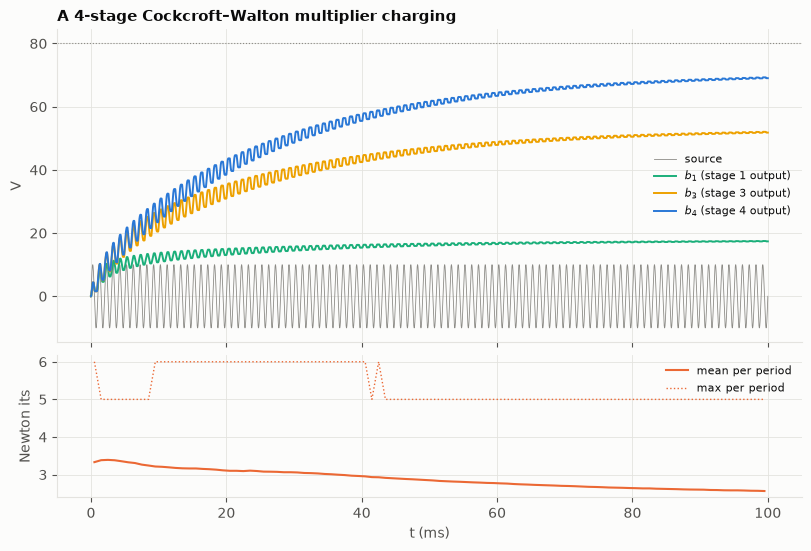

output over the last 2 periods: mean 69.11 V, ripple 0.407 V (ideal, unloaded: 80 V)


In [5]:
out = v_trace[:, b[STAGES]]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.4), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
ax1.plot(1e3 * t, V0 * np.sin(2 * np.pi * FREQ * t), color=plotstyle.NEUTRAL, lw=0.6, label="source")
for k, color in ((1, plotstyle.AQUA), (3, plotstyle.YELLOW), (STAGES, plotstyle.BLUE)):
  ax1.plot(1e3 * t, v_trace[:, b[k]], color=color, lw=1.4, label=f"$b_{k}$ (stage {k} output)")
ax1.axhline(2 * STAGES * V0, color=plotstyle.NEUTRAL, lw=0.8, ls=":")
ax1.set_ylabel("V")
ax1.set_title(f"A {STAGES}-stage Cockcroft–Walton multiplier charging")
ax1.legend(fontsize=8, loc="center right")
per_period = int(round(1 / (FREQ * H_STEP)))
its = newton_its[: STEPS // per_period * per_period].reshape(-1, per_period)
centres = 1e3 * (np.arange(its.shape[0]) + 0.5) / FREQ
ax2.plot(centres, its.mean(axis=1), color=plotstyle.ORANGE, lw=1.5, label="mean per period")
ax2.plot(centres, its.max(axis=1), color=plotstyle.ORANGE, lw=1, ls=":", label="max per period")
ax2.legend(fontsize=8, loc="upper right")
ax2.set_ylabel("Newton its")
ax2.set_xlabel("t (ms)")
plt.show()
last = t > t[-1] - 2e-3
print(f"output over the last 2 periods: mean {out[last].mean():.2f} V, ripple {np.ptp(out[last]):.3f} V (ideal, unloaded: {2 * STAGES * V0:.0f} V)")

## An independent check

The reference is a plain NumPy/SciPy implementation of the same trapezoidal–Newton scheme. It
stamps each element into a dense conductance matrix by hand and solves with `spsolve`. Its
Jacobian is therefore derived independently of Scaly's automatic one.

In [6]:
def reference(source, steps):
  inc = lambda p, q, n_br: sparse.csr_array(
    (np.r_[np.ones(n_br), -np.ones(n_br)], (np.r_[p, q], np.r_[np.arange(n_br), np.arange(n_br)])), shape=(N_NODES + 1, n_br)
  )[:N_NODES]
  a_cap, a_dio, a_res = inc(CAP_P, CAP_Q, len(CAP_P)), inc(DIO_P, DIO_Q, len(DIO_P)), inc(RES_P, RES_Q, len(RES_P))
  cmat = (CAP / H_STEP) * (a_cap @ a_cap.T)

  def diode(vd):
    vl = np.minimum(vd, V_CRIT)
    e = np.exp(vl / N_VT)
    return IS * (e * (1 + (vd - vl) / N_VT) - 1) + G_MIN * vd, IS * e / N_VT + G_MIN

  def f_and_g(v):
    i_d, g_d = diode(a_dio.T @ v)
    return a_res @ (RES_G * (a_res.T @ v)) + a_dio @ i_d, a_res @ sparse.diags_array(RES_G) @ a_res.T + a_dio @ sparse.diags_array(g_d) @ a_dio.T

  v, out = np.zeros(N_NODES), [np.zeros(N_NODES)]
  unit = np.eye(N_NODES)[0]
  for k in range(steps):
    f_old, _ = f_and_g(v)
    v_new = v.copy()
    for _ in range(50):
      f_new, g_new = f_and_g(v_new)
      F = cmat @ (v_new - v) + 0.5 * (f_new + f_old) - 0.5 * (source[k] + source[k + 1]) * unit
      dv = splinalg.spsolve(sparse.csc_array(cmat + 0.5 * g_new), F)
      v_new -= dv
      if np.abs(dv).max() < 1e-9:
        break
    v = v_new
    out.append(v)
  return np.array(out)


check_steps = 1500
start = time.perf_counter()
v_ref = reference(source, check_steps)
t_ref = time.perf_counter() - start
print(f"first {check_steps} steps: max |v_scaly - v_reference| = {np.abs(v_trace[: check_steps + 1] - v_ref).max():.1e} V")
print(f"reference: {1e3 * t_ref / check_steps:.2f} ms per step in Python, against {1e6 * run_time / STEPS:.1f} µs generated")

first 1500 steps: max |v_scaly - v_reference| = 7.8e-14 V
reference: 4.73 ms per step in Python, against 0.8 µs generated


## Same netlist, any input

The source samples are an argument, so the compiled simulator runs any waveform. Here the drive
amplitude halves after 50 ms. The output stops charging and then droops only slowly through the
load, because the diodes block and the capacitors hold their charge. The Jacobian's pattern is the
netlist's, so it never changes. Its ordering and elimination tree were computed once, in Python.
For a factorization this small, `SparseLDL` chose straight-line code.

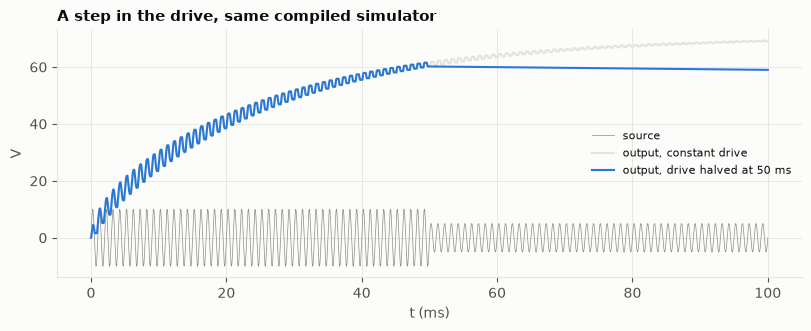

ordering auto:natural, nnz(L) = 14, work 34 flops: straight-line code


In [7]:
amplitude = np.where(t < 0.05, 1.0, 0.5)
trace_step = simulate(np.zeros(N_NODES), amplitude * source)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(1e3 * t, amplitude * V0 * np.sin(2 * np.pi * FREQ * t), color=plotstyle.NEUTRAL, lw=0.5, label="source")
ax.plot(1e3 * t[1:], trace[:, b[STAGES]], color=plotstyle.GRID, lw=1.5, label="output, constant drive")
ax.plot(1e3 * t[1:], trace_step[:, b[STAGES]], color=plotstyle.BLUE, lw=1.5, label="output, drive halved at 50 ms")
ax.set_xlabel("t (ms)")
ax.set_ylabel("V")
ax.set_title("A step in the drive, same compiled simulator")
ax.legend(fontsize=8, loc="center right")
plt.show()

fact = linalg.SparseLDL(linalg.SparseMatrix.from_sparse_jacobian(jac), name="probe")
print(
  f"ordering {fact.symbolic.method}, nnz(L) = {fact.symbolic.stats()['nnz_l']}, work {fact.work} flops: {'straight-line code' if fact.work <= 1000 else 'loops'}"
)

## The generated C

`simulate` is one C function: the time loop, the Newton loop, the residual, the compact Jacobian
and the factorization. It links nothing, so it could run inside a hardware-in-the-loop rig or a
co-simulation unit.

In [8]:
module = write_module(simulate, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB, workspace {module.workspace_size} doubles")

simulate.c: 255 lines, 15 kB, workspace 500000 doubles
